# SUPP-A: Gene Projection Rates Across R2 Assemblies

Strip/jitter plots showing Ensembl projection rates across ~400 haplotypes,
separated by biotype. Update of R1 figure panel.

**Input:** Pre-computed mapping stats CSVs (gene-level and transcript-level)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration - adjust paths as needed
GENE_STATS_CSV = Path('../../../../HPRC_2 - Mapping stats gene.csv')
TX_STATS_CSV = Path('../../../../HPRC_2 - Mapping stats transcript.csv')
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

COLORS = {
    'protein_coding': '#2e86c1',
    'noncoding': '#27ae60',
    'chm13': '#e67e22',  # T2T-CHM13 reference comparator
}

In [11]:
# Load mapping stats
gene_df = pd.read_csv(GENE_STATS_CSV)
tx_df = pd.read_csv(TX_STATS_CSV)

# Drop rows with all-empty stats (like GCA_41900165.1)
gene_df = gene_df.dropna(subset=['protein_coding_percentage'])
tx_df = tx_df.dropna(subset=['protein_coding_percentage'])

print(f"Gene stats: {len(gene_df)} assemblies")
print(f"Transcript stats: {len(tx_df)} assemblies")

Gene stats: 461 assemblies
Transcript stats: 461 assemblies


In [12]:
# Compute aggregate noncoding gene percentage
# Sum up all noncoding biotypes: lncRNA, miRNA, snoRNA, snRNA, etc.
noncoding_mapped_cols = [c for c in gene_df.columns if c.endswith('_mapped') 
                         and 'protein_coding' not in c 
                         and 'pseudogene' not in c
                         and 'artifact' not in c
                         and 'TEC' not in c]
noncoding_total_cols = [c.replace('_mapped', '_total') for c in noncoding_mapped_cols 
                        if c.replace('_mapped', '_total') in gene_df.columns]
noncoding_mapped_cols_valid = [c.replace('_total', '_mapped') for c in noncoding_total_cols]

gene_df['noncoding_mapped'] = gene_df[noncoding_mapped_cols_valid].sum(axis=1)
gene_df['noncoding_total'] = gene_df[noncoding_total_cols].sum(axis=1)
gene_df['noncoding_percentage'] = gene_df['noncoding_mapped'] / gene_df['noncoding_total'] * 100

# Same for transcripts
nc_tx_mapped = [c for c in tx_df.columns if c.endswith('_mapped') 
                and 'protein_coding' not in c 
                and 'pseudogene' not in c
                and 'artifact' not in c
                and 'TEC' not in c
                and 'CDS_not_defined' not in c
                and 'LoF' not in c]
nc_tx_total = [c.replace('_mapped', '_total') for c in nc_tx_mapped 
               if c.replace('_mapped', '_total') in tx_df.columns]
nc_tx_mapped_valid = [c.replace('_total', '_mapped') for c in nc_tx_total]

tx_df['noncoding_mapped'] = tx_df[nc_tx_mapped_valid].sum(axis=1)
tx_df['noncoding_total'] = tx_df[nc_tx_total].sum(axis=1)
tx_df['noncoding_percentage'] = tx_df['noncoding_mapped'] / tx_df['noncoding_total'] * 100

/tmp/ipykernel_1931049/298405362.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tx_df['noncoding_mapped'] = tx_df[nc_tx_mapped_valid].sum(axis=1)
/tmp/ipykernel_1931049/298405362.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tx_df['noncoding_total'] = tx_df[nc_tx_total].sum(axis=1)
/tmp/ipykernel_1931049/298405362.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.conca

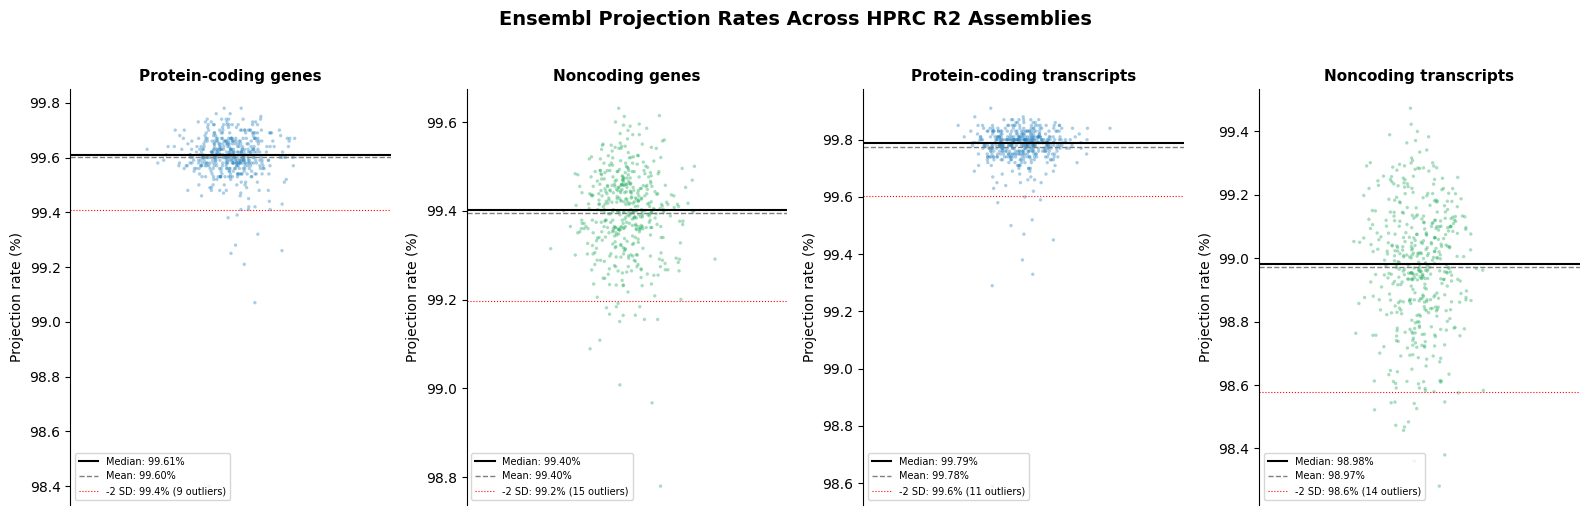

Saved to figures/figure_supp_a_projection_rates.png


In [17]:
# --- SUPP-A Figure: 4-panel strip/jitter plots ---
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

panels = [
    ('Protein-coding genes', gene_df['protein_coding_percentage'], COLORS['protein_coding']),
    ('Noncoding genes', gene_df['noncoding_percentage'], COLORS['noncoding']),
    ('Protein-coding transcripts', tx_df['protein_coding_percentage'], COLORS['protein_coding']),
    ('Noncoding transcripts', tx_df['noncoding_percentage'], COLORS['noncoding']),
]

for ax, (title, data, color) in zip(axes, panels):
    data = data.dropna()
    jitter = np.random.normal(0, 0.15, len(data))
    ax.scatter(jitter, data, alpha=0.4, s=6, color=color, edgecolors='none')
    
    # Median line
    med = data.median()
    ax.axhline(med, color='black', linewidth=1.5, linestyle='-', label=f'Median: {med:.2f}%')
    
    # Mean line
    mean = data.mean()
    ax.axhline(mean, color='grey', linewidth=1, linestyle='--', label=f'Mean: {mean:.2f}%')
    
    # 2 SD below mean threshold
    threshold = mean - 2 * data.std()
    n_outliers = (data < threshold).sum()
    if n_outliers > 0:
        ax.axhline(threshold, color='red', linewidth=0.8, linestyle=':', 
                   label=f'-2 SD: {threshold:.1f}% ({n_outliers} outliers)')
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Projection rate (%)', fontsize=10)
    ax.set_xlim(-1, 1)
    ax.set_xticks([])
    ax.legend(fontsize=7, loc='lower left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

fig.suptitle('Ensembl Projection Rates Across HPRC R2 Assemblies', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_supp_a_projection_rates.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'figure_supp_a_projection_rates.pdf', bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'figure_supp_a_projection_rates.png'}")

In [14]:
# Save processed projection rates as intermediate spreadsheet
projection_summary = gene_df[['genbank_accession', 'protein_coding_percentage', 
                               'protein_coding_mapped', 'protein_coding_total',
                               'noncoding_percentage', 'noncoding_mapped', 'noncoding_total']].copy()
projection_summary.to_csv(OUTPUT_DIR / 'projection_rates_per_assembly.tsv', sep='\t', index=False)
print(f"Saved projection rates spreadsheet")

Saved projection rates spreadsheet


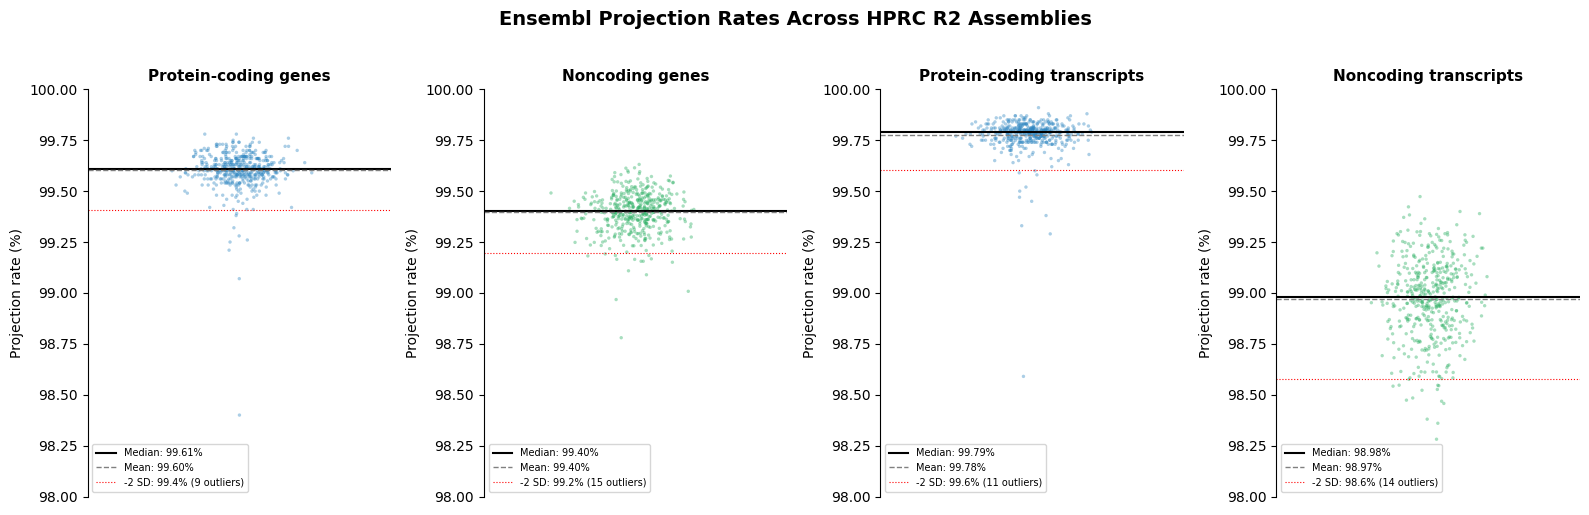

Saved to figures/figure_supp_a_projection_rates_0-100.png


In [20]:
# --- SUPP-A Figure: 4-panel strip/jitter plots ---
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

panels = [
    ('Protein-coding genes', gene_df['protein_coding_percentage'], COLORS['protein_coding']),
    ('Noncoding genes', gene_df['noncoding_percentage'], COLORS['noncoding']),
    ('Protein-coding transcripts', tx_df['protein_coding_percentage'], COLORS['protein_coding']),
    ('Noncoding transcripts', tx_df['noncoding_percentage'], COLORS['noncoding']),
]

for ax, (title, data, color) in zip(axes, panels):
    data = data.dropna()
    jitter = np.random.normal(0, 0.15, len(data))
    ax.scatter(jitter, data, alpha=0.4, s=6, color=color, edgecolors='none')
    
    # Median line
    med = data.median()
    ax.axhline(med, color='black', linewidth=1.5, linestyle='-', label=f'Median: {med:.2f}%')
    
    # Mean line
    mean = data.mean()
    ax.axhline(mean, color='grey', linewidth=1, linestyle='--', label=f'Mean: {mean:.2f}%')
    
    # 2 SD below mean threshold
    threshold = mean - 2 * data.std()
    n_outliers = (data < threshold).sum()
    if n_outliers > 0:
        ax.axhline(threshold, color='red', linewidth=0.8, linestyle=':', 
                   label=f'-2 SD: {threshold:.1f}% ({n_outliers} outliers)')
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Projection rate (%)', fontsize=10)

    ax.set_xlim(-1, 1)
    ax.set_ylim(98, 100)  # ← fixed 0–100 range

    ax.set_xticks([])
    ax.legend(fontsize=7, loc='lower left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

fig.suptitle('Ensembl Projection Rates Across HPRC R2 Assemblies', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_supp_a_projection_rates_0-100.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'figure_supp_a_projection_rates_0-100.pdf', bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'figure_supp_a_projection_rates_0-100.png'}")